## Import libraries

In [1]:
import tomopy
from helperFunctions import MoviePlotter
from tomoDataClass import tomoData, simulate_projections
from alignment_methods import sinogram_consistency_score, reconstruction_sharpness_score

## Create Simulated Data

In [2]:
#Set constants
numAngles = 556 #Number of projection angles
imageSize = 256 #Pixel size of one side of cubic array containing Shepp3D phantom

#Create a simulated object
obj = tomopy.shepp3d(size=imageSize)
print(obj.shape)
print("Simulated Object")
MoviePlotter(obj) #Plots vertical slices through the phantom

(256, 256, 256)
Simulated Object


Output()

In [3]:
import numpy as np
# Set projection angles
angles = tomopy.angles(nang=numAngles, ang1=-71.99, ang2=58.80)
# angles = tomopy.angles(nang=numAngles, ang1=-90, ang2=90)

# create projection images/sinogram
projections = simulate_projections(obj, angles, pad=False, use_astra=True)
# pad projections to be 30 pixels larger on each side
projections = np.pad(projections, ((0, 0), (30, 30), (30, 30)), mode='constant', constant_values=0)

print("Projections through object")
MoviePlotter(projections)

ASTRA forward projection failed (No module named 'astra'), falling back to tomopy.project
Projections through object


Output()



Normalizing projections


Using CPU-based reconstruction. Algorithm:  gridrec
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Reconstruction completed.

Bad reconstruction prior to alignment


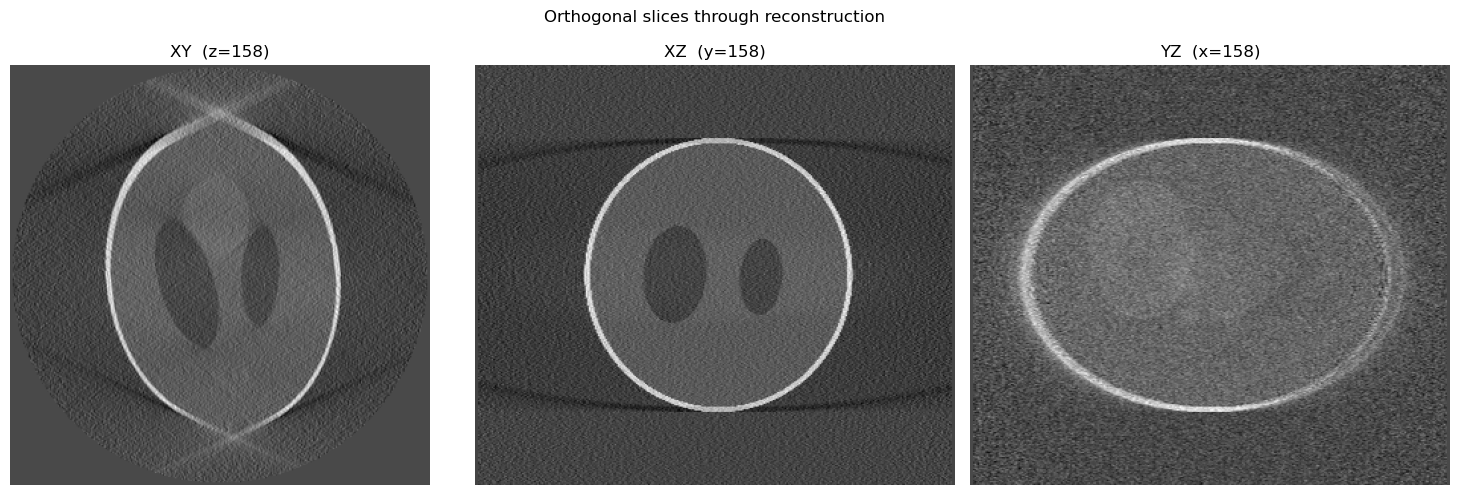

In [4]:
#Shift angles to be centered around 0
angles = angles - np.mean(angles)

# Show missing wedge artifacts in reconstruction
tomo = tomoData(projections, angles)
tomo.add_noise()
#Show bad reconstruction prior to alignment
# tomo.reset_workingProjections(x_size=imageSize, y_size=imageSize) #You can adjust these for tighter cropping
tomo.normalize(isPhaseData=True)

tomo.reconstruct(algorithm='gridrec')
print("\nBad reconstruction prior to alignment")
badRecon = tomo.recon.copy()
# MoviePlotter(badRecon)
tomo.displayReconOrthogonalSlices()

Applying Kovacik filter: 100%|██████████| 316/316 [00:04<00:00, 77.26it/s]


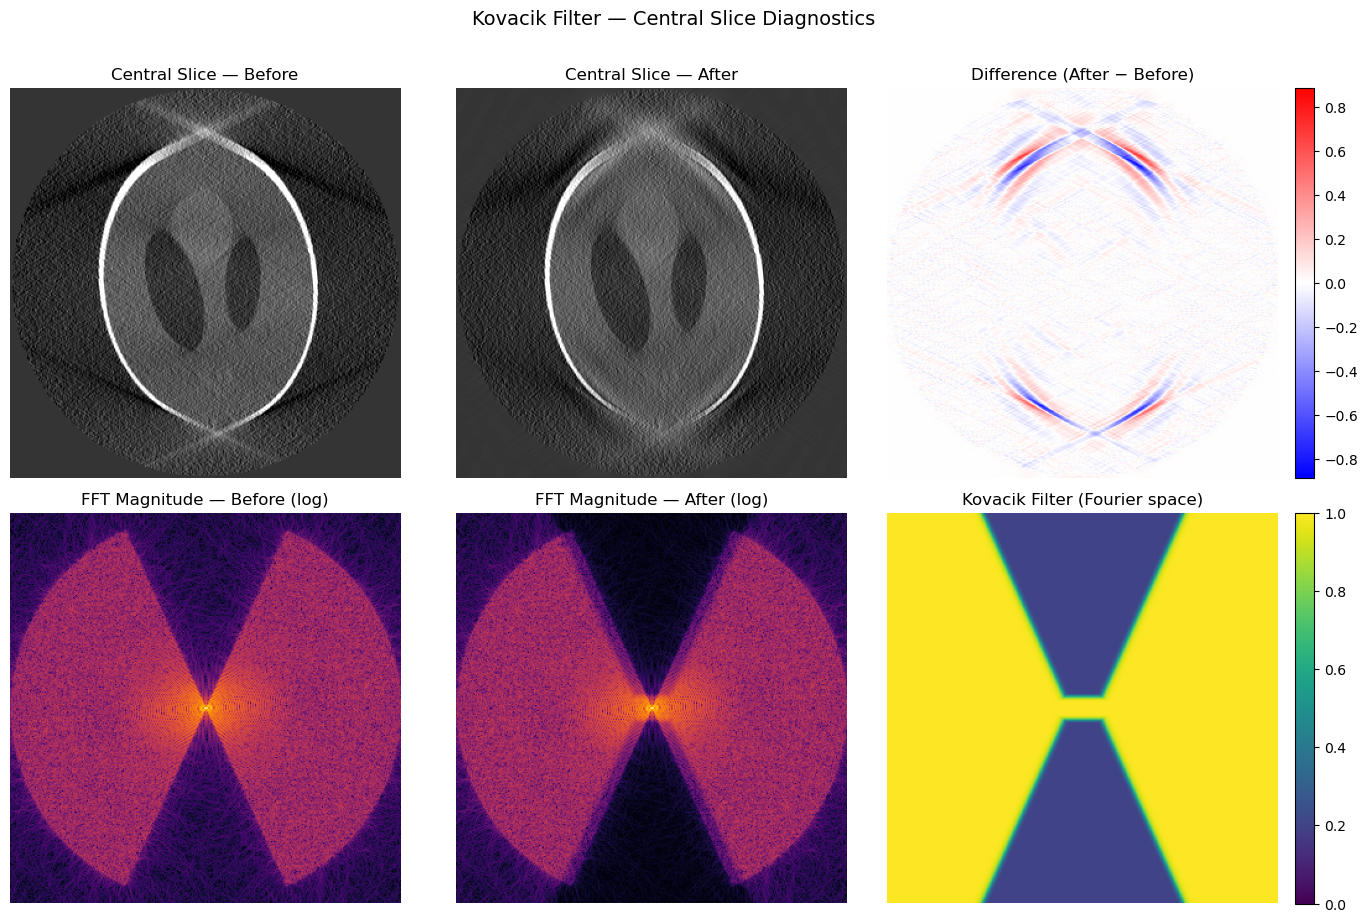

Kovacik filter applied.


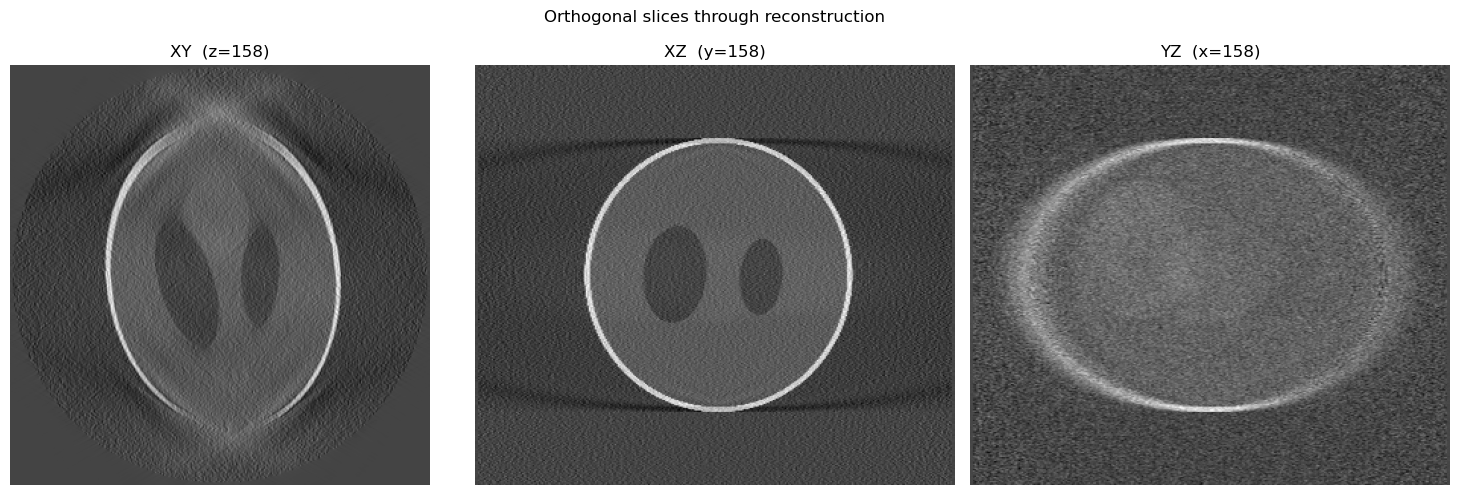

In [20]:
tomo.kovacik_filter(
    tilt_max=np.max(angles)+0.01,  # correct — keep
    mwr_length=10,             # tighten the ramp
    mwr_order=4,               # steep roll-off → stays near the boundary, preserves interior signal
    mwr_wmin=0.2,              # slightly less aggressive than 0.05
    cs_cutoff=10,               # keep
    cs_order=4,                # keep
    plot=True
)
tomo.displayReconOrthogonalSlices()

In [ ]:
### Back to original Processing pipeline

In [ ]:
tomo = tomoData(projections, angles)
tomo.jitter(maxShift = 6)
# tomo.add_noise()
print("Projections through Object with jitter and noise")

tomo.data = -tomo.data[::,0:imageSize//2] #Invert the data to make it look more like real projections
tomo.reset_workingProjections()
tomo.makeNotebookProjMovie()

## Align Data

In [ ]:
#Show bad reconstruction prior to alignment
tomo.reset_workingProjections(x_size=imageSize, y_size=imageSize) #You can adjust these for tighter cropping
tomo.normalize(isPhaseData=True)

tomo.reconstruct(algorithm='art')
print("\nBad reconstruction prior to alignment")
badRecon = tomo.recon.copy()
MoviePlotter(badRecon)

In [ ]:
# Sinogram consistency score — before alignment
combined_rmse_before, x_rmse_before, y_rmse_before, _, _ = sinogram_consistency_score(tomo, plot=True)

# Baseline sharpness — before alignment
grad_before, lap_before, _, _ = reconstruction_sharpness_score(badRecon, plot=True, percentile_crop=5)
print(f"\nBaseline  →  Gradient: {grad_before:.6f}  |  Laplacian: {lap_before:.6f}")

In [ ]:

# # ── VMF Parameter Search ─────────────────────────────────────────────────────
# # Sweeps sigma, smooth_sigma, window, roi_sigma, and use_gradient.
# # Uses max_iterations=5 per run; swap algorithm to 'gridrec' for a faster sweep.
# import itertools
# import pandas as pd
# from tqdm.notebook import tqdm as tqdm_nb

# RECON_ALG    = 'art'   # change to 'gridrec' or 'fbp' for a much faster sweep
# MAX_ITER_VMF = 10

# sigmas        = [None, 1.0, 2.0, 3.0, 4.0]        # None → auto (image_height / 128)
# smooth_sigmas = [1.0]
# windows       = ['soft_roi']
# roi_sigmas    = [0.3]         # only active when window='soft_roi'
# use_gradients = [True]

# # Build config list: roi_sigma only varies for soft_roi; fix it at 0.3 otherwise
# configs = []
# for use_gradient, window, sigma, smooth_sigma in itertools.product(
#         use_gradients, windows, sigmas, smooth_sigmas):
#     if window == 'soft_roi':
#         for roi_sigma in roi_sigmas:
#             configs.append(dict(sigma=sigma, smooth_sigma=smooth_sigma,
#                                 window=window, roi_sigma=roi_sigma,
#                                 use_gradient=use_gradient))
#     else:
#         configs.append(dict(sigma=sigma, smooth_sigma=smooth_sigma,
#                             window=window, roi_sigma=0.3,
#                             use_gradient=use_gradient))

# print(f"Configurations to test: {len(configs)}")

# # Seed the results table with the pre-alignment baseline
# rows = [dict(sigma='baseline', smooth_sigma='—', window='—', roi_sigma='—',
#              use_gradient='—', sino_rmse=combined_rmse_before,
#              grad=grad_before, lap=lap_before)]

# for cfg in tqdm_nb(configs, desc='VMF param search'):
#     tomo.reset_workingProjections(x_size=imageSize, y_size=imageSize)
#     tomo.normalize(isPhaseData=True)

#     tomo.vertical_mass_fluctuation_align(
#         tolerance=0, max_iterations=MAX_ITER_VMF, y_range=None, plot=False, **cfg
#     )
#     tomo.make_updates_shift()
#     tomo.reconstruct(algorithm=RECON_ALG)

#     sino_rmse, _, _, _, _ = sinogram_consistency_score(tomo, plot=False)
#     grad, lap, _, _       = reconstruction_sharpness_score(tomo.recon, plot=False, percentile_crop=5)

#     rows.append({**cfg, 'sino_rmse': sino_rmse, 'grad': grad, 'lap': lap})

# # ── Results table ─────────────────────────────────────────────────────────────
# df = pd.DataFrame(rows)

# # Rank by sinogram RMSE (lower = better), then show sharpness scores (higher = better)
# df_sorted = df.sort_values('sino_rmse').reset_index(drop=True)
# df_sorted.index.name = 'rank'

# # Format floats for readability
# for col in ('sino_rmse', 'grad', 'lap'):
#     df_sorted[col] = df_sorted[col].apply(
#         lambda x: f'{x:.6f}' if isinstance(x, float) else x)

# print("\n── VMF Parameter Search Results (sorted by sinogram RMSE, lower = better) ──")
# print(df_sorted.to_string())


In [ ]:
tomo.reset_workingProjections(x_size=imageSize, y_size=imageSize)
tomo.normalize(isPhaseData=True)

#Best XC params from sweep:
# Coarse passes: stepRatio=0.9 (stable global convergence)
tomo.cross_correlate_align(tolerance=0, maxShiftTolerance=0, max_iterations=15, stepRatio=0.9, yROI_Range=None, xROI_Range=None, isFull360=False, downsample=4, use_grad=True)
tomo.cross_correlate_align(tolerance=0, maxShiftTolerance=0, max_iterations=15, stepRatio=0.9, yROI_Range=None, xROI_Range=None, isFull360=False, downsample=2, use_grad=True)
# Final pass: stepRatio=0.75-0.8 with more iterations (fine-scale sharpness)
tomo.cross_correlate_align(tolerance=0, maxShiftTolerance=0, max_iterations=30, stepRatio=0.8, yROI_Range=None, xROI_Range=None, isFull360=False, downsample=1, use_grad=True)


#Best VMF params from sweep:
# tomo.vertical_mass_fluctuation_align(tolerance=0, max_iterations=1, y_range=None, sigma=None, smooth_sigma=1.0, window='soft_roi', roi_sigma=0.3, use_gradient=True, plot=True)

tomo.PMA(max_iterations=5, tolerance=0, algorithm='art', levels=3, scale=2, iterations_per_level=[5,5,2], shift_method='optical_flow', of_sigma=3.0, plot=True)
tomo.make_updates_shift()

In [ ]:
tomo.makeNotebookProjMovie()

tomo.reconstruct(algorithm='art')
print("\nGood Reconstruction after alignment")
tomo.makeNotebookReconMovie()

In [ ]:

# Sinogram consistency score — after alignment
combined_rmse_after, x_rmse_after, y_rmse_after, _, _ = sinogram_consistency_score(tomo, plot=True)

# Reconstruction sharpness score — after alignment
grad_after, lap_after, _, _ = reconstruction_sharpness_score(tomo.recon, plot=True, percentile_crop=5)

print("=" * 62)
print("  ALIGNMENT QUALITY SUMMARY")
print("=" * 62)
print(f"\n{'Sinogram Consistency  (lower RMSE = better)':}")
print(f"  {'Metric':<22} {'Before':>10} {'After':>10} {'Δ (improvement)':>16}")
print(f"  {'-'*60}")
print(f"  {'X RMSE (px)':<22} {x_rmse_before:>10.4f} {x_rmse_after:>10.4f} {x_rmse_before - x_rmse_after:>+16.4f}")
print(f"  {'Y RMSE (px)':<22} {y_rmse_before:>10.4f} {y_rmse_after:>10.4f} {y_rmse_before - y_rmse_after:>+16.4f}")
print(f"  {'Combined RMSE (px)':<22} {combined_rmse_before:>10.4f} {combined_rmse_after:>10.4f} {combined_rmse_before - combined_rmse_after:>+16.4f}")

print(f"\n{'Reconstruction Sharpness':}")
print(f"  {'Metric':<22} {'Before':>10} {'After':>10} {'Δ (improvement)':>16}")
print(f"  {'-'*60}")
print(f"  {'Gradient':<22} {grad_before:>10.6f} {grad_after:>10.6f} {grad_after - grad_before:>+16.6f}")
print(f"  {'Laplacian variance':<22} {lap_before:>10.6f} {lap_after:>10.6f} {lap_after - lap_before:>+16.6f}")
print("=" * 62)